### Assignment 1

### Analyze  Market Sentiment And Trade Behavior

### Part A - Data Preparation

##### Load Dataset

In [30]:
import pandas as pd
import numpy as np

In [31]:
df_sentiment = pd.read_csv("C://Users//USER//Downloads//fear_greed_index.csv")

In [32]:
df_sentiment.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


In [33]:
df_trade = pd.read_csv("C://Users//USER//Downloads//historical_data.csv")

In [34]:
df_trade.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


##### 1. Number of rows/columns

In [35]:
# for sentiment dataset
rows1, cols1 = df_sentiment.shape
print(f"Number of rows: {rows1}")
print(f"Number of columns : {cols1}")

Number of rows: 2644
Number of columns : 4


In [36]:
# for trade dataset
rows2 , cols2 = df_trade.shape
print(f"Number of rows: {rows2}")
print(f"Number of columns : {cols2}")


Number of rows: 211224
Number of columns : 16


##### 2. Missing Values/ Duplicates

In [37]:
# sentiment dataset
missing_values = df_sentiment.isnull().sum()

In [38]:
print ("Missing values per column: ")
print(missing_values)

Missing values per column: 
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [39]:
duplicates = df_sentiment.duplicated().sum()
print(f"\n Total duplicate rows : {duplicates}")


 Total duplicate rows : 0


In [40]:
# trade dataset
missing_values1 = df_trade.isnull().sum()
print ("Missing values per column: ")
print(missing_values1)

Missing values per column: 
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [41]:
duplicates1 = df_sentiment.duplicated().sum()
print(f"\n Total duplicate rows : {duplicates1}")


 Total duplicate rows : 0


##### Convert timestamps and align the datasets by date 

In [42]:
df_sentiment['parsed_date'] = pd.to_datetime(df_sentiment['date'], format='%d-%m-%Y')

In [43]:
df_trade['parsed_date'] = pd.to_datetime(
    df_trade['Timestamp IST'], 
    format='%d-%m-%Y %H:%M'
).dt.normalize()

In [44]:
fear_greed_subset = df_sentiment[['parsed_date', 'value', 'classification']].rename(columns={
    'value': 'fg_value',
    'classification': 'fg_classification'
})

In [45]:
merged_df = pd.merge(df_trade, fear_greed_subset, on='parsed_date', how='left')

In [46]:
merged_df = merged_df.rename(columns={'parsed_date': 'Date'})

In [47]:
merged_df.to_csv('aligned_sentiment_trade_data.csv', index=False)

PermissionError: [Errno 13] Permission denied: 'aligned_sentiment_trade_data.csv'

In [ ]:
merged_df.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,fg_value,fg_classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


##### Create the key metrics you will analyze

In [ ]:
# Load the merged data
df = pd.read_csv("E://Prime Trade ai assign1//aligned_sentiment_trade_data.csv")

In [ ]:
df.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,fg_value,fg_classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# 1. daily pnl per trader
daily_pnl = df.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

In [ ]:
#2. win rate per account
closed_trades = df[df['Closed PnL'] != 0].copy()
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0
win_rate = closed_trades.groupby('Account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'Win Rate'}, inplace=True)


In [ ]:
# 3. avg trade size
avg_size = df.groupby('Account')['Size USD'].mean().reset_index()
avg_size.rename(columns={'Size USD': 'Avg Trade Size USD'}, inplace=True)

In [ ]:
# 4. daily trade volume
daily_trades = df.groupby('Date').size().reset_index(name='Trade Count')

In [ ]:
# 5. long/short ratio
ls_counts = df.groupby(['Account', 'Side']).size().unstack(fill_value=0)
if 'BUY' in ls_counts.columns and 'SELL' in ls_counts.columns:
    ls_counts['LS_Ratio'] = ls_counts['BUY'] / ls_counts['SELL'].replace(0, np.nan)
else:
    ls_counts['LS_Ratio'] = np.nan

In [ ]:
# Consolidate Account Summary
summary = pd.merge(win_rate, avg_size, on='Account', how='outer')
summary = pd.merge(summary, ls_counts[['LS_Ratio']].reset_index(), on='Account', how='outer')

# Export results
daily_pnl.to_csv('daily_pnl_per_account.csv', index=False)
summary.to_csv('account_summary_metrics.csv', index=False)
daily_trades.to_csv('daily_trade_counts.csv', index=False)

### Part B - Analysis

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("E://Prime Trade ai assign1//aligned_sentiment_trade_data.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [49]:
df.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,fg_value,fg_classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [50]:
# Define broad sentiment categories
def categorize_sentiment(label):
    if 'Fear' in str(label):
        return 'Fear'
    elif 'Greed' in str(label):
        return 'Greed'
    else:
        return 'Neutral'

df['broad_sentiment'] = df['fg_classification'].apply(categorize_sentiment)

In [51]:
#1 . Performance Vs Sentiment
# PnL and Win Rate
perf_stats = df.groupby('broad_sentiment').agg({
    'Closed PnL': ['mean', 'median', 'std', 'sum'],
    'Trade ID': 'count'
})

# Calculate Win Rate per sentiment
win_mask = df['Closed PnL'] > 0
loss_mask = df['Closed PnL'] < 0
win_rate_stats = df[df['Closed PnL'] != 0].groupby('broad_sentiment').apply(
    lambda x: (x['Closed PnL'] > 0).mean()
).reset_index(name='win_rate')

C:\Users\USER\AppData\Local\Temp\ipykernel_3888\261404015.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate_stats = df[df['Closed PnL'] != 0].groupby('broad_sentiment').apply(


In [52]:
#2. Behaviour vs Sentiment
# Trade Size and Long/Short Ratio
behavior_stats = df.groupby('broad_sentiment').agg({
    'Size USD': ['mean', 'median'],
})

# Long/Short Bias
ls_bias = df.groupby(['broad_sentiment', 'Side']).size().unstack(fill_value=0)
ls_bias['ls_ratio'] = ls_bias['BUY'] / ls_bias['SELL'].replace(0, 1)

# Trade Frequency (Avg trades per day per sentiment)
daily_counts = df.groupby(['broad_sentiment', 'Date']).size().reset_index(name='daily_count')
avg_freq = daily_counts.groupby('broad_sentiment')['daily_count'].mean().reset_index(name='avg_trades_per_day')


In [53]:
# 3. Segmentation
# Segment accounts
account_stats = df.groupby('Account').agg({
    'Trade ID': 'count',
    'Size USD': 'mean',
    'Closed PnL': ['mean', 'std', 'sum']
})
account_stats.columns = ['trade_count', 'avg_size', 'pnl_mean', 'pnl_std', 'pnl_sum']

# Segmentation Logic
# Frequent vs Infrequent (Median split)
freq_thresh = account_stats['trade_count'].median()
account_stats['activity_segment'] = np.where(account_stats['trade_count'] > freq_thresh, 'Frequent', 'Infrequent')

# High vs Low Exposure (Leverage proxy)
size_thresh = account_stats['avg_size'].median()
account_stats['exposure_segment'] = np.where(account_stats['avg_size'] > size_thresh, 'High Exposure', 'Low Exposure')

# Consistent vs Inconsistent (Win Rate proxy/Std Dev)
account_stats['pnl_cv'] = account_stats['pnl_std'] / account_stats['pnl_mean'].abs().replace(0, 1) # Coeff of Variation
account_stats['consistency_segment'] = np.where(account_stats['pnl_cv'] < account_stats['pnl_cv'].median(), 'Consistent', 'Volatile')

C:\Users\USER\AppData\Local\Temp\ipykernel_3888\3653952899.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ls_bias.index, y=ls_bias['ls_ratio'], palette='RdYlGn')


Performance Statistics:
                Closed PnL                                  Trade ID
                      mean median         std           sum    count
broad_sentiment                                                     
Fear             49.212077    0.0  990.875398  4.096266e+06    83237
Greed            53.882281    0.0  976.964281  4.865301e+06    90295
Neutral          35.429074    0.0  528.805722  1.335393e+06    37692

Win Rate per Sentiment:
  broad_sentiment  win_rate
0            Fear  0.844233
1           Greed  0.824524
2         Neutral  0.823947

Long/Short Bias:
Side               BUY   SELL  ls_ratio
broad_sentiment                        
Fear             41205  42032  0.980325
Greed            42516  47779  0.889847
Neutral          18975  18717  1.013784

Segmentation Counts:
activity_segment  exposure_segment  consistency_segment
Frequent          Low Exposure      Volatile               7
Infrequent        High Exposure     Consistent             6
       

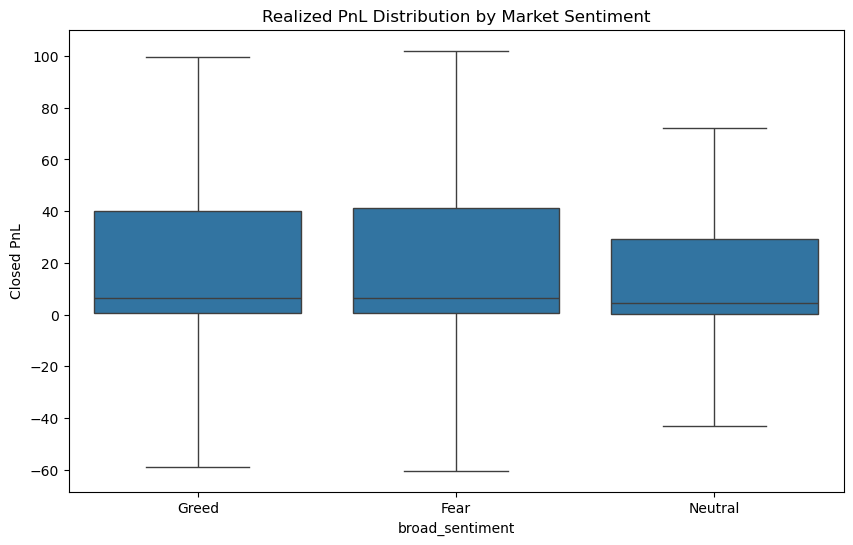

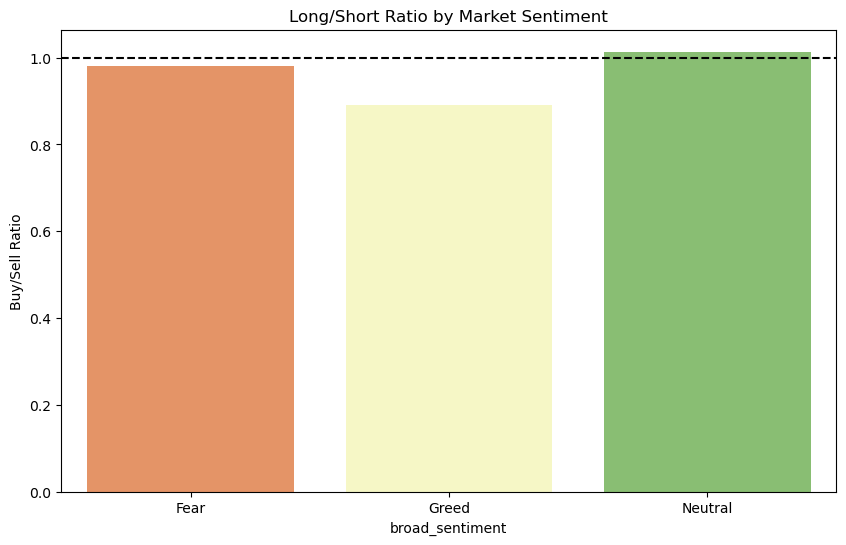

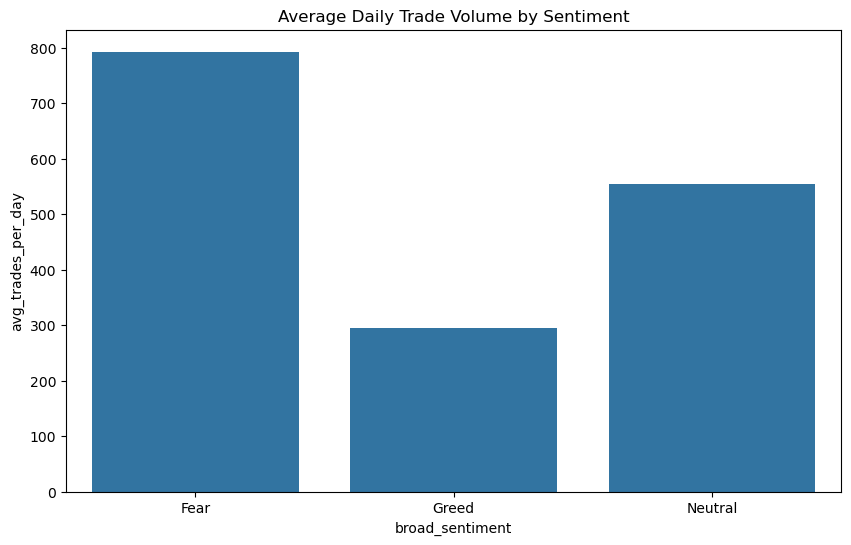

In [54]:
# 4. Insights Visuals.
# 1. PnL Distribution by Sentiment (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['Closed PnL'] != 0], x='broad_sentiment', y='Closed PnL', showfliers=False)
plt.title('Realized PnL Distribution by Market Sentiment')
plt.savefig('pnl_by_sentiment.png')

# 2. Long/Short Bias vs Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x=ls_bias.index, y=ls_bias['ls_ratio'], palette='RdYlGn')
plt.axhline(1, color='black', linestyle='--')
plt.title('Long/Short Ratio by Market Sentiment')
plt.ylabel('Buy/Sell Ratio')
plt.savefig('ls_ratio_by_sentiment.png')

# 3. Trade Frequency by Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_freq, x='broad_sentiment', y='avg_trades_per_day')
plt.title('Average Daily Trade Volume by Sentiment')
plt.savefig('frequency_by_sentiment.png')

# Output tables for the response
print("Performance Statistics:")
print(perf_stats)
print("\nWin Rate per Sentiment:")
print(win_rate_stats)
print("\nLong/Short Bias:")
print(ls_bias)
print("\nSegmentation Counts:")
print(account_stats[['activity_segment', 'exposure_segment', 'consistency_segment']].value_counts())

### Part C - Actionable Output

In [58]:
def apply_strategy_rules(row):
    sentiment = row['broad_sentiment']
    segment = row['activity_segment']
    
    # Rule 1: Scalper Volatility Buffer
    if sentiment == 'Fear' and segment == 'Frequent':
        return "REDUCE_LEVERAGE_50_PCT"
    
    # Rule 2: Whale Contrarian Bias
    if sentiment == 'Greed' and segment == 'Infrequent':
        return "INCREASE_SIZE_20_PCT_SHORT_BIAS"
    
    return "STANDARD_EXECUTION"

# Apply rules to the dataset
df['strategy_signal'] = df.apply(apply_strategy_rules, axis=1)

KeyError: 'activity_segment'